<a href="https://colab.research.google.com/github/thilakghub/content-creation-learn/blob/main/autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from torchvision import datasets, transforms

In [29]:
# Load and preprocess MNIST data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

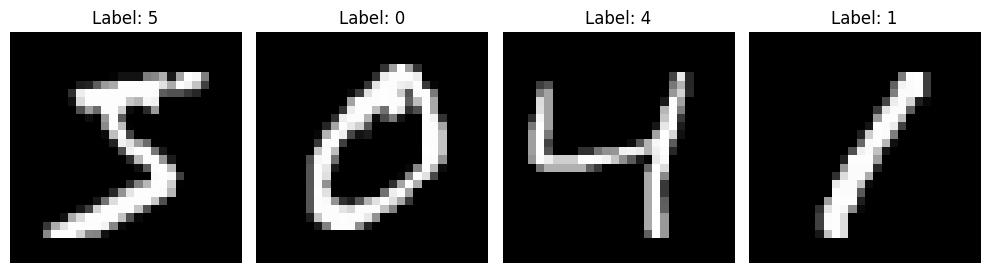

In [30]:
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [31]:
x_train[0].shape

(28, 28, 1)

In [38]:
x_train.shape

(60000, 28, 28, 1)

In [32]:
x_train = torch.from_numpy(x_train)
# Create a DataLoader to handle batching of the training data
train_loader = torch.utils.data.DataLoader(
    x_train, batch_size=1, shuffle=True
)

In [24]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Set the number of hidden units
        self.encoding_dim = 8

        # Define the encoder part of the autoencoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),  # input size: 784, output size: 256
            nn.ReLU(),  # apply the ReLU activation function
            nn.Linear(256, self.encoding_dim),  # input size: 256, output size: encoding_dim
            nn.ReLU(),  # apply the ReLU activation function
        )

        # Define the decoder part of the autoencoder
        self.decoder = nn.Sequential(
            nn.Linear(self.encoding_dim, 256),  # input size: encoding_dim, output size: 256
            nn.ReLU(),  # apply the ReLU activation function
            nn.Linear(256, 784),  # input size: 256, output size: 784
            nn.Sigmoid(),  # apply the sigmoid activation function to compress the output to a range of (0, 1)
        )

    def forward(self, x):
        # Pass the input through the encoder
        encoded = self.encoder(x)
        # Pass the encoded representation through the decoder
        decoded = self.decoder(encoded)
        # Return both the encoded representation and the reconstructed output
        return encoded, decoded

In [26]:
learning_rate = 0.001

# Create the autoencoder model and optimizer
model = AutoEncoder()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Define the loss function
criterion = nn.MSELoss()

In [ ]:
num_epochs = 10

# Training loop
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_idx, data in enumerate(train_loader):

        data = data.view(data.size(0), -1)

        # Forward pass
        encoded, decoded = model(data)

        # Compute the loss and perform backpropagation
        loss = criterion(decoded, data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update the running loss
        total_loss += loss.item() * data.size(0)

    # Print the epoch loss
    epoch_loss = total_loss / len(train_loader.dataset)
    print(
        "Epoch {}/{}: loss={:.4f}".format(epoch + 1, num_epochs, epoch_loss)
    )

In [ ]:
# prompt: write a autoencoder for image dataset using pytorch

# Hyperparameters
input_size = 784  # 28x28 image
encoding_dim = 32
learning_rate = 0.001
num_epochs = 10

# Initialize the autoencoder model
autoencoder = Autoencoder(input_size, encoding_dim)

# Define the loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    for data in train_loader_pytorch:
        img, _ = data
        img = img.view(img.size(0), -1)  # Flatten the image
        # Forward pass
        outputs = autoencoder(img)
        loss = criterion(outputs, img)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Test the autoencoder
with torch.no_grad():
    for data in train_loader_pytorch:
        img, _ = data
        img = img.view(img.size(0), -1)
        outputs = autoencoder(img)

        # Display original and reconstructed images
        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(img.view(28, 28).numpy(), cmap='gray')
        plt.title('Original Image')
        plt.subplot(1, 2, 2)
        plt.imshow(outputs.view(28, 28).detach().numpy(), cmap='gray')
        plt.title('Reconstructed Image')
        plt.show()
        break # Display only one example


Using Pytorch dataset

In [5]:
# Define the transformation to convert images to PyTorch tensors
transform = transforms.Compose([transforms.ToTensor()])

# Load the MNIST dataset with the specified transformation
mnist_pytorch = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Create a DataLoader to load the dataset in batches
train_loader_pytorch = torch.utils.data.DataLoader(mnist_pytorch, batch_size=1, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 343kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.97MB/s]


<Figure size 1500x300 with 0 Axes>

<Figure size 1500x300 with 0 Axes>

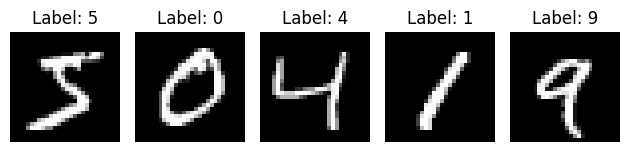

In [6]:
# Create a figure to display the images
plt.figure(figsize=(15, 3))

# Print the first few images in a row
for i, (image, label) in enumerate(train_loader_pytorch):
    if i < 5:  # Print the first 5 samples
        plt.subplot(1, 5, i + 1)
        plt.imshow(image[0].squeeze(), cmap='gray')
        plt.title(f"Label: {label.item()}")
        plt.axis('off')
    else:
        break  # Exit the loop after printing 5 samples

plt.tight_layout()
plt.show()